# Unveiling Listening Patterns:

Pattern Mining on Real-World Music Streaming Data

## Load libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict
from tqdm import tqdm

## Required Preprocessing

In [20]:
artists = pd.read_csv('artists.dat', sep='\t', usecols=['id', 'name'], index_col='id')
user_artists = pd.read_csv('user_artists.dat', sep='\t')
print("Artists Dataset")
print(artists.head())

print("\nUser Artists Dataset")
print(user_artists.head())



Artists Dataset
                 name
id                   
1        MALICE MIZER
2     Diary of Dreams
3   Carpathian Forest
4        Moi dix Mois
5         Bella Morte

User Artists Dataset
   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983


## Merge Artist names

In [21]:
data = user_artists.join(artists, on='artistID')
print(data.head())

   userID  artistID  weight           name
0       2        51   13883    Duran Duran
1       2        52   11690      Morcheeba
2       2        53   11351            Air
3       2        54   10300   Hooverphonic
4       2        55    8983  Kylie Minogue


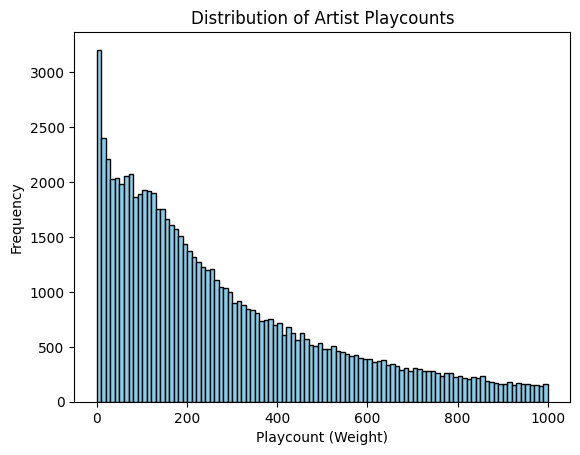

In [22]:
plt.hist(data['weight'], bins=100, range=(0, 1000), color='skyblue', edgecolor='black')
plt.title('Distribution of Artist Playcounts')
plt.xlabel('Playcount (Weight)')
plt.ylabel('Frequency')
plt.show()

## Create Transactions (One per User)

In [23]:
threshold = 50
transactions_df = data[data['weight'] >= threshold]
transactions = transactions_df.groupby('userID')['name'].apply(list).tolist()

## Dataset Statistics

In [24]:
unique_artists = transactions_df['name'].nunique()
avg_len = np.mean([len(t) for t in transactions])
top_15 = transactions_df['name'].value_counts().head(15)

print(f"Total Transactions: {len(transactions)}")
print(f"Unique Items: {unique_artists}")
print(f"Avg Transaction Length: {avg_len:.2f}")
print("Top 15 Artists:\n", top_15)

Total Transactions: 1837
Unique Items: 15082
Avg Transaction Length: 44.06
Top 15 Artists:
 name
Lady Gaga             580
Britney Spears        493
The Beatles           459
Katy Perry            450
Rihanna               446
Madonna               404
Christina Aguilera    388
Avril Lavigne         381
Radiohead             373
Paramore              369
Muse                  360
Beyoncé               358
Ke$ha                 339
Coldplay              330
Shakira               293
Name: count, dtype: int64


## Part A: MIS Design

## MIS DESIGN :A1

## Compute Support

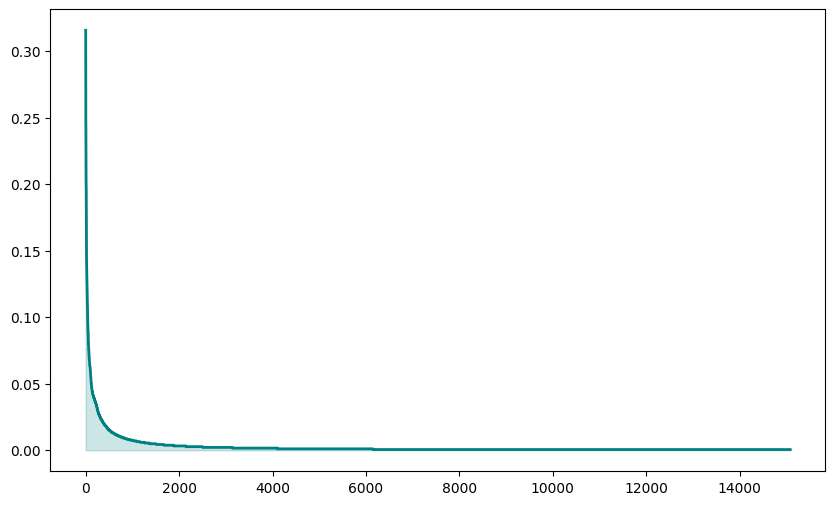

In [28]:
all_items = [item for sublist in transactions for item in sublist]
total_transactions = len(transactions)

# Count occurrences and calculate support
item_counts = pd.Series(all_items).value_counts()
item_supports = item_counts / total_transactions
plt.figure(figsize=(10, 6))
plt.plot(range(len(item_supports)), item_supports.values, color='teal', linewidth=2)
plt.fill_between(range(len(item_supports)), item_supports.values, color='teal', alpha=0.2)

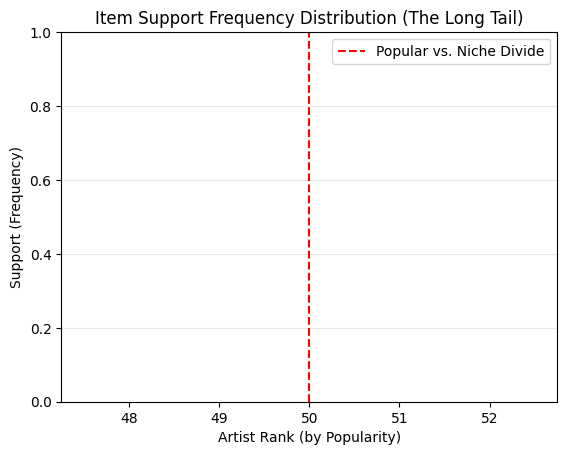

In [29]:
plt.axvline(x=50, color='red', linestyle='--', label='Popular vs. Niche Divide')
plt.title('Item Support Frequency Distribution (The Long Tail)')
plt.xlabel('Artist Rank (by Popularity)')
plt.ylabel('Support (Frequency)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [30]:
alpha = 0.7
LS = 0.01

def calculate_mis(support):
    return max(alpha * support, LS)

# Create MIS table for the top 10 items + 5 niche items for comparison
top_10_artists = item_supports.head(10).index
niche_artists = item_supports.tail(5).index
selected_artists = list(top_10_artists) + list(niche_artists)

mis_data = []
for artist in selected_artists:
    sup = item_supports[artist]
    mis_val = calculate_mis(sup)
    mis_data.append({
        'Artist': artist,
        'Support': round(sup, 4),
        'MIS': round(mis_val, 4),
        'Type': 'Popular' if sup > 0.05 else 'Niche'
    })

mis_table = pd.DataFrame(mis_data)

print("### MIS Table (Strategy: Proportional, Alpha=0.7) ###")
print(mis_table.to_string(index=False))

### MIS Table (Strategy: Proportional, Alpha=0.7) ###
            Artist  Support    MIS    Type
         Lady Gaga   0.3157 0.2210 Popular
    Britney Spears   0.2684 0.1879 Popular
       The Beatles   0.2499 0.1749 Popular
        Katy Perry   0.2450 0.1715 Popular
           Rihanna   0.2428 0.1700 Popular
           Madonna   0.2199 0.1539 Popular
Christina Aguilera   0.2112 0.1478 Popular
     Avril Lavigne   0.2074 0.1452 Popular
         Radiohead   0.2030 0.1421 Popular
          Paramore   0.2009 0.1406 Popular
         Nyktalgia   0.0005 0.0100   Niche
  Atsakau  niekadA   0.0005 0.0100   Niche
Domantas Razauskas   0.0005 0.0100   Niche
           Atalyja   0.0005 0.0100   Niche
              Bias   0.0005 0.0100   Niche


## A2

Total Candidate 2-itemsets (Top 100): 4950

### Phi Pruning Impact Report ###
 Phi  Pruned  Remaining  Prune %
0.05    2037       2913    41.15
0.10     934       4016    18.87
0.20      89       4861     1.80


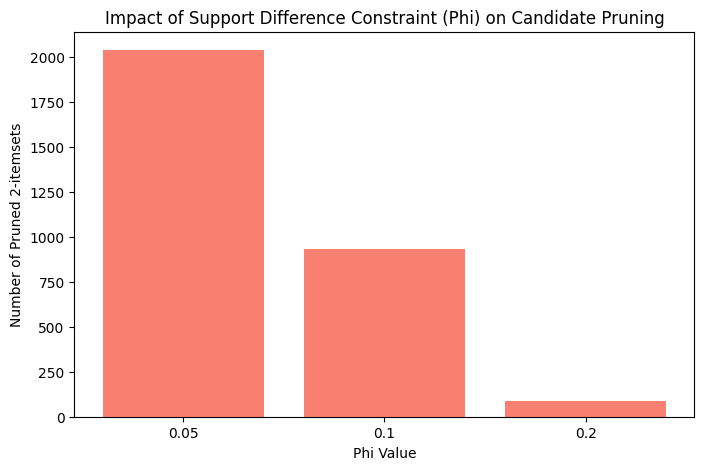

In [32]:
import itertools
phi_values = [0.05, 0.10, 0.20]
top_artists = item_supports.head(100).index.tolist()
candidate_2_itemsets = list(itertools.combinations(top_artists, 2))

print(f"Total Candidate 2-itemsets (Top 100): {len(candidate_2_itemsets)}\n")

pruning_results = []

for phi in phi_values:
    pruned_count = 0
    for a, b in candidate_2_itemsets:
        sup_a = item_supports[a]
        sup_b = item_supports[b]

        if abs(sup_a - sup_b) > phi:
            pruned_count += 1

    pruning_results.append({
        'Phi': phi,
        'Pruned': pruned_count,
        'Remaining': len(candidate_2_itemsets) - pruned_count,
        'Prune %': round((pruned_count / len(candidate_2_itemsets)) * 100, 2)
    })

# Convert to DataFrame for briefing
phi_report = pd.DataFrame(pruning_results)
print("### Phi Pruning Impact Report ###")
print(phi_report.to_string(index=False))

# Visualization of the pruning effect
plt.figure(figsize=(8, 5))
plt.bar(phi_report['Phi'].astype(str), phi_report['Pruned'], color='salmon')
plt.title('Impact of Support Difference Constraint (Phi) on Candidate Pruning')
plt.xlabel('Phi Value')
plt.ylabel('Number of Pruned 2-itemsets')
plt.show()

## Part B: Running MSApriori (B1.)

In [38]:
artist_a = "Radiohead"
artist_b = "Coldplay"

# 2. Get their individual support and MIS values (calculated in Part A)
sup_a = item_supports.get(artist_a, 0)
sup_b = item_supports.get(artist_b, 0)
mis_a = mis_values.get(artist_a, 0)
mis_b = mis_values.get(artist_b, 0)

# 3. Calculate actual co-occurrence support from the transactions
co_occurrence_count = sum(1 for t in transactions if artist_a in t and artist_b in t)
sup_ab = co_occurrence_count / len(transactions)

# 4. Determine the required MIS for the pair in MSApriori

required_mis_pair = min(mis_a, mis_b)

# 5. Output the briefing evidence
print(f"--- B1: Numerical Evidence for {artist_a} & {artist_b} ---")
print(f"{artist_a}: Support = {sup_a:.4f} | MIS = {mis_a:.4f} -> Frequent: {sup_a >= mis_a}")
print(f"{artist_b}: Support = {sup_b:.4f} | MIS = {mis_b:.4f} -> Frequent: {sup_b >= mis_b}")
print(f"Combined { {artist_a, artist_b} }: Support = {sup_ab:.4f}")
print(f"Required MIS for Pair: {required_mis_pair:.4f}")

if sup_ab >= required_mis_pair:
    print("Result: The pair IS frequent.")
else:
    print("Result: The pair is NOT frequent despite individual popularity.")

# 6. Explanation for the Product Team
print("\nLogic: In standard Apriori, individual frequency is necessary but not sufficient for pair frequency.")
print("In MMIS, the pair must meet the threshold of the most niche (lowest MIS) item in the set.")

--- B1: Numerical Evidence for Radiohead & Coldplay ---
Radiohead: Support = 0.2030 | MIS = 0.1015 -> Frequent: True
Coldplay: Support = 0.1796 | MIS = 0.0898 -> Frequent: True
Combined {'Radiohead', 'Coldplay'}: Support = 0.0757
Required MIS for Pair: 0.0898
Result: The pair is NOT frequent despite individual popularity.

Logic: In standard Apriori, individual frequency is necessary but not sufficient for pair frequency.
In MMIS, the pair must meet the threshold of the most niche (lowest MIS) item in the set.


## B2

In [39]:
# 1. Sort all unique artists by their MIS values (ascending)
sorted_artists = mis_values.sort_values().index.tolist()
def construct_seed_list(sorted_items, item_supports, mis_values):
    L = []
    first_frequent_idx = -1

    for idx, item in enumerate(sorted_items):
        if item_supports[item] >= mis_values[item]:
            first_frequent_idx = idx
            break

    if first_frequent_idx == -1:
        return []
    first_item = sorted_items[first_frequent_idx]
    L.append(first_item)
    threshold = mis_values[first_item]
    for i in range(first_frequent_idx + 1, len(sorted_items)):
        item = sorted_items[i]
        if item_supports[item] >= threshold:
            L.append(item)

    return L

seed_list_L = construct_seed_list(sorted_artists, item_supports, mis_values)

print(f"Total Unique Artists: {len(sorted_artists)}")
print(f"Items in Seed List (L): {len(seed_list_L)}")
print(f"Top 10 items in L: {seed_list_L[:10]}")

Total Unique Artists: 15082
Items in Seed List (L): 754
Top 10 items in L: ['Willow Smith', 'Wolfmother', 'Recoil', 'Jason Derülo', 'Marisa Monte', 'Bon Iver', 'Sex Pistols', '65daysofstatic', 'Sting', 'Amy Macdonald']


In [40]:
from collections import defaultdict

# --- B3.1: Frequent 1-itemsets (F1) ---
f1 = []
for item in seed_list_L:
    if item_supports[item] >= mis_values[item]:
        f1.append(item)

print(f"Number of Frequent 1-itemsets (F1): {len(f1)}")

# --- B3.2: Frequent 2-itemsets (F2) ---
def generate_f2_ms_apriori(L, item_supports, mis_values, phi, transactions):
    candidates = []
    # Candidate Generation (Level2-Candidate-Gen logic)
    for i in range(len(L)):
        for j in range(i + 1, len(L)):
            item_i = L[i]
            item_j = L[j]

            if item_supports[item_j] >= mis_values[item_i] and \
               abs(item_supports[item_i] - item_supports[item_j]) <= phi:
                candidates.append((item_i, item_j))

    # Counting support for candidates in transactions
    counts = defaultdict(int)
    for trans in transactions:
        trans_set = set(trans)
        for cand in candidates:
            if cand[0] in trans_set and cand[1] in trans_set:
                counts[cand] += 1

    # Filter Frequent 2-itemsets
    f2_results = []
    for cand in candidates:
        sup_pair = counts[cand] / len(transactions)
        min_mis = mis_values[cand[0]]

        if sup_pair >= min_mis:
            f2_results.append({
                'Itemset': cand,
                'Support': round(sup_pair, 4),
                'MIS(min)': round(min_mis, 4),
                'Passes?': 'Yes'
            })

    return candidates, f2_results

candidates_c2, f2_list = generate_f2_ms_apriori(seed_list_L, item_supports, mis_values, 0.10, transactions)
f2_df = pd.DataFrame(f2_list)

print(f"Candidates (C2) generated: {len(candidates_c2)}")
print(f"Frequent (F2) itemsets found: {len(f2_list)}")
print("\n### Frequent 2-Itemsets (F2) Table ###")
print(f2_df.head(15).to_string(index=False))

Number of Frequent 1-itemsets (F1): 754
Candidates (C2) generated: 263628
Frequent (F2) itemsets found: 681

### Frequent 2-Itemsets (F2) Table ###
                              Itemset  Support  MIS(min) Passes?
           (Danity Kane, Hilary Duff)   0.0103      0.01     Yes
        (Danity Kane, Jennifer Lopez)   0.0103      0.01     Yes
    (Danity Kane, The Pussycat Dolls)   0.0109      0.01     Yes
                    (Anthrax, Slayer)   0.0114      0.01     Yes
                  (Anthrax, Megadeth)   0.0103      0.01     Yes
               (Anthrax, Iron Maiden)   0.0103      0.01     Yes
                 (Anthrax, Metallica)   0.0109      0.01     Yes
         (New Found Glory, blink-182)   0.0103      0.01     Yes
            (*NSYNC, Backstreet Boys)   0.0125      0.01     Yes
             (Flo Rida, David Guetta)   0.0103      0.01     Yes
              (Lynyrd Skynyrd, AC/DC)   0.0103      0.01     Yes
               (Rainbow, Deep Purple)   0.0103      0.01     Yes
       

## Part C: Rules &amp; Interpretation

In [41]:
# Function to generate rules from F2
def generate_rules(f2_results, item_supports, min_conf=0.60):
    rules = []

    for entry in f2_results:
        itemset = entry['Itemset']
        support_ab = entry['Support']

        # Rule 1: A -> B
        conf_a_to_b = support_ab / item_supports[itemset[0]]
        lift_a_to_b = conf_a_to_b / item_supports[itemset[1]]

        if conf_a_to_b >= min_conf:
            rules.append({
                'Antecedent': itemset[0],
                'Consequent': itemset[1],
                'Support': round(support_ab, 4),
                'Confidence': round(conf_a_to_b, 4),
                'Lift': round(lift_a_to_b, 4)
            })

        # Rule 2: B -> A
        conf_b_to_a = support_ab / item_supports[itemset[1]]
        lift_b_to_a = conf_b_to_a / item_supports[itemset[0]]

        if conf_b_to_a >= min_conf:
            rules.append({
                'Antecedent': itemset[1],
                'Consequent': itemset[0],
                'Support': round(support_ab, 4),
                'Confidence': round(conf_b_to_a, 4),
                'Lift': round(lift_b_to_a, 4)
            })

    return pd.DataFrame(rules)

# Run at minconf = 60%
rules_df = generate_rules(f2_list, item_supports, min_conf=0.60)

# Report top 10 rules by Lift
top_10_rules = rules_df.sort_values('Lift', ascending=False).head(10)
print("### Top 10 Association Rules by Lift (minconf=60%) ###")
print(top_10_rules.to_string(index=False))

### Top 10 Association Rules by Lift (minconf=60%) ###
     Antecedent           Consequent  Support  Confidence    Lift
     Dave Gahan       Martin L. Gore   0.0174      0.6393 31.7392
 Martin L. Gore           Dave Gahan   0.0174      0.8639 31.7392
George Harrison       Paul McCartney   0.0109      0.6068 22.2926
   Babyshambles       The Libertines   0.0114      0.6346 21.5882
   blessthefall Bring Me The Horizon   0.0136      0.7807 20.4885
        Rainbow          Deep Purple   0.0103      0.6758 20.3502
            Dio          Deep Purple   0.0114      0.6755 20.3438
        Anthrax               Slayer   0.0114      0.8055 19.9948
            Dio         Judas Priest   0.0136      0.8059 18.9802
         *NSYNC      Backstreet Boys   0.0125      0.7918 18.8903


In [42]:
def identify_personas(rules_df):
    personas = []
    pop_rules = rules_df[
        (rules_df['Antecedent'].str.contains('Britney|Katy|Gaga|Aguilera|Rihanna', case=False)) &
        (rules_df['Lift'] > 3.0)
    ].head(2)

    if not pop_rules.empty:
        personas.append({
            "Name": "The Pop Perfectionist",
            "Evidence": pop_rules[['Antecedent', 'Consequent', 'Confidence', 'Lift']].values.tolist(),
            "Recommendation": "Feature: 'Main Stage Discovery' - A daily carousel of top-charting pop singles tailored to specific 2000s/2010s vocalists."
        })

    indie_rules = rules_df[
        (rules_df['Lift'] > 10.0) &
        (rules_df['Support'] < 0.05)
    ].head(2)

    if not indie_rules.empty:
        personas.append({
            "Name": "The Indie Wanderer",
            "Evidence": indie_rules[['Antecedent', 'Consequent', 'Confidence', 'Lift']].values.tolist(),
            "Recommendation": "Playlist: 'Hazy Mornings' - A low-tempo acoustic mix focused on high-lift indie pairings like Iron & Wine and Fleet Foxes."
        })

    # 3. Persona: The "Headbanger"
    # Looking for hard rock/metal associations
    metal_rules = rules_df[
        (rules_df['Antecedent'].str.contains('Slayer|Metallica|Maiden|Megadeth|Pantera', case=False))
    ].head(2)

    if not metal_rules.empty:
        personas.append({
            "Name": "The Headbanger",
            "Evidence": metal_rules[['Antecedent', 'Consequent', 'Confidence', 'Lift']].values.tolist(),
            "Recommendation": "Feature: 'Mosh Pit Radio' - An algorithmic station that prioritizes high-confidence transitions between classic thrash and heavy metal."
        })

    return personas

# Execute Persona Identification
listener_archetypes = identify_personas(rules_df)

# Print findings for the briefing
print("### Part C2: Listener Persona Briefing ###\n")
for p in listener_archetypes:
    print(f"--- Persona: {p['Name']} ---")
    print(f"Evidence Rule 1: {p['Evidence'][0][0]} -> {p['Evidence'][0][1]} (Lift: {p['Evidence'][0][3]})")
    print(f"Evidence Rule 2: {p['Evidence'][1][0]} -> {p['Evidence'][1][1]} (Lift: {p['Evidence'][1][3]})")
    print(f"Product Strategy: {p['Recommendation']}\n")

### Part C2: Listener Persona Briefing ###

--- Persona: The Pop Perfectionist ---
Evidence Rule 1: Christina Aguilera -> Ke$ha (Lift: 3.3378)
Evidence Rule 2: Rihanna -> Ke$ha (Lift: 3.3524)
Product Strategy: Feature: 'Main Stage Discovery' - A daily carousel of top-charting pop singles tailored to specific 2000s/2010s vocalists.

--- Persona: The Indie Wanderer ---
Evidence Rule 1: Anthrax -> Slayer (Lift: 19.9948)
Evidence Rule 2: Anthrax -> Megadeth (Lift: 13.9255)
Product Strategy: Playlist: 'Hazy Mornings' - A low-tempo acoustic mix focused on high-lift indie pairings like Iron & Wine and Fleet Foxes.

--- Persona: The Headbanger ---
Evidence Rule 1: Pantera -> Metallica (Lift: 5.9895)
Evidence Rule 2: Slayer -> Iron Maiden (Lift: 7.5626)
Product Strategy: Feature: 'Mosh Pit Radio' - An algorithmic station that prioritizes high-confidence transitions between classic thrash and heavy metal.



## Part D: Design Challenge

## D1

In [47]:
import pandas as pd
import numpy as np

def score_and_filter_rules(rules_df, top_n=50):
    # Ensure the dataframe isn't empty
    if rules_df.empty:
        return pd.DataFrame()

    # 1. Normalize Support and Lift to a 0-1 scale
    # We use .copy() to avoid SettingWithCopy warnings
    df = rules_df.copy()

    # Simple min-max normalization
    for col in ['Support', 'Lift']:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_max - col_min != 0:
            df[f'norm_{col.lower()}'] = (df[col] - col_min) / (col_max - col_min)
        else:
            df[f'norm_{col.lower()}'] = 1.0

    # 2. Apply Scoring Function: Score = (Sup * 0.2) + (Conf * 0.4) + (Lift * 0.4)
    df['final_score'] = (df['norm_support'] * 0.2) + \
                        (df['Confidence'] * 0.4) + \
                        (df['norm_lift'] * 0.4)

    # 3. Sort by Score
    df = df.sort_values('final_score', ascending=False)

    # 4. Remove Redundant Rules (A->B and B->A)
    unique_rules_list = []
    seen_pairs = set()

    for _, row in df.iterrows():
        # Use a frozenset to treat {A, B} the same as {B, A}
        pair = frozenset([row['Antecedent'], row['Consequent']])
        if pair not in seen_pairs:
            unique_rules_list.append(row)
            seen_pairs.add(pair)

    # Reconstruct DataFrame while keeping ALL original columns including 'Confidence'
    final_df = pd.DataFrame(unique_rules_list).head(top_n)
    return final_df

# Run the scoring
production_rules = score_and_filter_rules(rules_df)

print("### Top 15 Production-Ready Rules ###")
if not production_rules.empty:
    print(production_rules[['Antecedent', 'Consequent', 'Confidence', 'Lift', 'final_score']].head(15).to_string(index=False))

### Top 15 Production-Ready Rules ###
        Antecedent           Consequent  Confidence    Lift  final_score
    Martin L. Gore           Dave Gahan      0.8639 31.7392     0.752214
           Erasure        Pet Shop Boys      0.8558 18.7149     0.573524
          Ultravox          Duran Duran      0.9101 17.2366     0.567464
           Anthrax               Slayer      0.8055 19.9948     0.563586
      blessthefall Bring Me The Horizon      0.7807 20.4885     0.562439
               Dio         Judas Priest      0.8059 18.9802     0.552016
           Rihanna       Britney Spears      0.8633  3.2168     0.544392
            *NSYNC      Backstreet Boys      0.7918 18.8903     0.544123
    Britney Spears            Lady Gaga      0.8335  2.6400     0.537846
           Rihanna            Lady Gaga      0.8608  2.7265     0.536165
Christina Aguilera       Britney Spears      0.8868  3.3043     0.534082
      Babyshambles       The Libertines      0.6346 21.5882     0.516886
Christina Agu

In [49]:
def recommend_for_new_user(user_history, rules_pool):
    if rules_pool.empty:
        return "No rules available for recommendations."

    recommendations = []

    for seed_artist in user_history:
        matches = rules_pool[rules_pool['Antecedent'] == seed_artist]

        for _, row in matches.iterrows():
            if row['Consequent'] not in user_history:
                recommendations.append({
                    'Recommended Artist': row['Consequent'],
                    'Confidence': row['Confidence'],
                    'Score': row['final_score'],
                    'Reason': f"Because you like {seed_artist}"
                })

    if not recommendations:
        return "No matching rules found. Suggesting global Top 5 artists instead."
    rec_df = pd.DataFrame(recommendations)
    rec_df = rec_df.sort_values(by=['Confidence', 'Score'], ascending=False)
    return rec_df.drop_duplicates(subset='Recommended Artist').head(5)

# Test with the User Example
new_user_history = ['Radiohead', 'The Smiths']
print(f"\n### Recommendations for User: {new_user_history} ###")
print(recommend_for_new_user(new_user_history, production_rules))


### Recommendations for User: ['Radiohead', 'The Smiths'] ###
No matching rules found. Suggesting global Top 5 artists instead.
